# CO2 Emissions Modeling

This notebook implements the full pipeline from [plan.md](plan.md):
1. Load data, time-based splits, scaling, evaluation
2. PCA (scree, loadings, interpretation)
3. Regression (linear, Ridge, Lasso, Elastic Net)
4. Clustering (K-means on PCA scores)
5. Feedforward neural network
6. LSTM for panel time-series
7. GNN (optional, graph from similarity)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('cleaned_co2_data_20vars.csv')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)

TARGET = 'co2_per_capita'
ID_COLS = ['country', 'year', 'iso_code']
NUMERIC_COLS = [
    'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp',
    'co2', 'co2_per_capita', 'total_ghg', 'consumption_co2', 'methane', 'nitrous_oxide',
    'cement_co2', 'flaring_co2', 'trade_co2', 'coal_co2', 'gas_co2', 'oil_co2'
]
PREDICTOR_COLS = [c for c in NUMERIC_COLS if c != TARGET]

## 1. Load data, splits, scaling

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Years:', df['year'].min(), '-', df['year'].max())

train = df[(df['year'] >= 1990) & (df['year'] <= 2015)].copy()
val   = df[(df['year'] >= 2016) & (df['year'] <= 2019)].copy()
test  = df[(df['year'] >= 2020) & (df['year'] <= 2022)].copy()
print('Train:', len(train), '| Val:', len(val), '| Test:', len(test))

Shape: (2640, 20)
Years: 1990 - 2022
Train: 2017 | Val: 354 | Test: 269


In [3]:
scaler_X = StandardScaler()
X_train = pd.DataFrame(
    scaler_X.fit_transform(train[PREDICTOR_COLS]),
    columns=PREDICTOR_COLS,
    index=train.index
)
X_val   = pd.DataFrame(scaler_X.transform(val[PREDICTOR_COLS]),   columns=PREDICTOR_COLS, index=val.index)
X_test  = pd.DataFrame(scaler_X.transform(test[PREDICTOR_COLS]),  columns=PREDICTOR_COLS, index=test.index)
y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values

def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }

print('Scaling done. Predictors:', len(PREDICTOR_COLS))

Scaling done. Predictors: 16


## 2. PCA

In [4]:
pca = PCA()
pca.fit(X_train)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_85 = np.argmax(cumvar >= 0.85) + 1
print('Components for 85% variance:', n_85)
print('Components for 90% variance:', n_90)

Components for 85% variance: 3
Components for 90% variance: 4


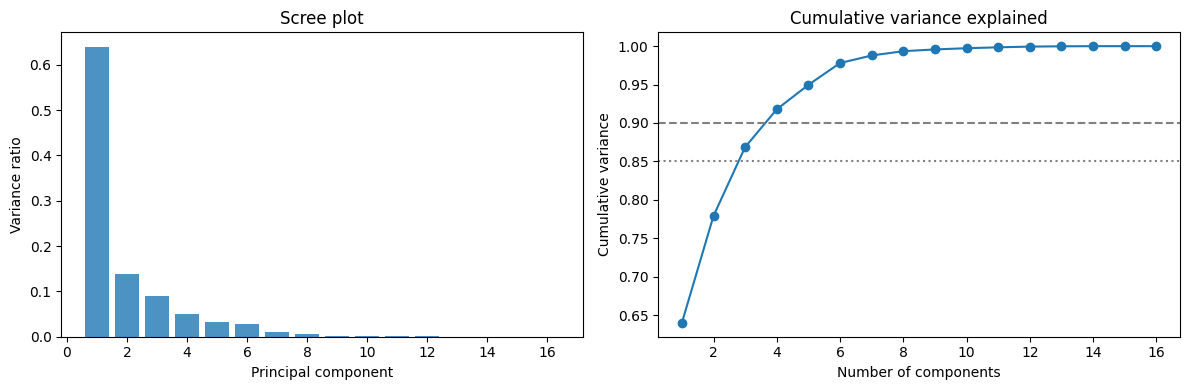

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.8)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance ratio')
axes[0].set_title('Scree plot')
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-')
axes[1].axhline(0.9, color='gray', linestyle='--')
axes[1].axhline(0.85, color='gray', linestyle=':')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative variance explained')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'pca_scree.png', dpi=150)
plt.show()

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=PREDICTOR_COLS
)
print('Loadings (first 5 components):')
display(loadings.iloc[:, :5].round(3))
loadings.to_csv(OUTPUT_DIR / 'tables' / 'pca_loadings.csv')

Loadings (first 5 components):


,PC1,PC2,PC3,PC4,PC5
population,0.235,-0.311,-0.047,0.071,0.564
gdp,0.294,0.130,-0.123,-0.191,-0.018
primary_energy_consumption,0.304,0.116,-0.007,-0.099,-0.159
energy_per_capita,0.017,0.317,0.553,-0.420,0.407
energy_per_gdp,0.022,0.142,0.714,0.229,-0.060
co2,0.308,0.022,0.020,-0.108,-0.180
total_ghg,0.308,-0.006,-0.019,0.000,0.012
consumption_co2,0.304,0.084,-0.028,-0.171,-0.149
methane,0.290,-0.086,-0.052,0.201,0.374
nitrous_oxide,0.294,-0.122,-0.041,0.044,0.306


In [7]:
n_components = max(n_85, 5)
train_scores = pca.transform(X_train)[:, :n_components]
val_scores   = pca.transform(X_val)[:, :n_components]
test_scores  = pca.transform(X_test)[:, :n_components]
print('Using', n_components, 'components for downstream models.')

Using 5 components for downstream models.


## 3. Regression

In [8]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}
results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
        pred = m.predict(X)
        results.append({'model': name, 'split': split_name, **evaluate(y, pred)})
results_df = pd.DataFrame(results)
display(results_df)

,model,split,RMSE,MAE,R2
0,Linear,val,3.566520,1.664840,0.653608
1,Linear,test,3.535777,1.637055,0.619788
2,Ridge,val,3.382289,1.539367,0.688469
3,Ridge,test,3.270271,1.482077,0.674745
4,Lasso,val,3.353151,1.536473,0.693814
5,Lasso,test,3.214860,1.464996,0.685674
6,ElasticNet,val,3.394140,1.559013,0.686283
7,ElasticNet,test,3.140430,1.468256,0.700060


In [9]:
lm = LinearRegression()
lm.fit(X_train, y_train)
coef_df = pd.DataFrame({'predictor': PREDICTOR_COLS, 'coefficient': lm.coef_}).sort_values('coefficient', key=abs, ascending=False)
coef_df.to_csv(OUTPUT_DIR / 'tables' / 'linear_coefficients.csv', index=False)
print('Top predictors (by |coefficient|):')
display(coef_df.head(10))

Top predictors (by |coefficient|):


,predictor,coefficient
5,co2,3.440215e+06
7,consumption_co2,-3.237524e+06
12,trade_co2,4.872009e+05
13,coal_co2,4.450345e+01
2,primary_energy_consumption,-2.809100e+01
15,oil_co2,2.666950e+01
14,gas_co2,1.350125e+01
3,energy_per_capita,7.127519e+00
1,gdp,4.890388e+00
0,population,-2.273436e+00


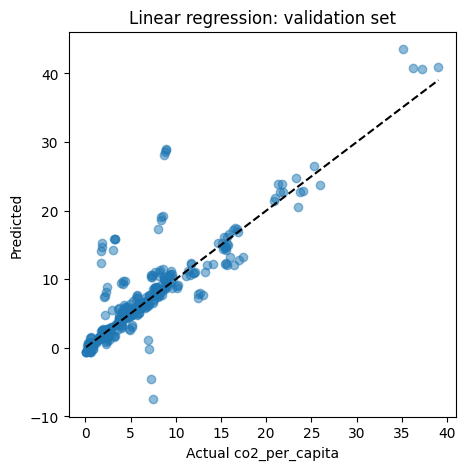

In [10]:
pred_val = lm.predict(X_val)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_val, pred_val, alpha=0.5)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
ax.set_xlabel('Actual co2_per_capita')
ax.set_ylabel('Predicted')
ax.set_title('Linear regression: validation set')
plt.savefig(OUTPUT_DIR / 'figures' / 'regression_residuals.png', dpi=150)
plt.show()

In [11]:
lm_pca = LinearRegression()
lm_pca.fit(train_scores, y_train)
pred_val_pca = lm_pca.predict(val_scores)
pred_test_pca = lm_pca.predict(test_scores)
print('Regression on PCA scores:')
print('  Val:', evaluate(y_val, pred_val_pca))
print('  Test:', evaluate(y_test, pred_test_pca))

Regression on PCA scores:
  Val: {'RMSE': np.float64(3.5632413869244144), 'MAE': 2.0040017152468375, 'R2': 0.6542441521241782}
  Test: {'RMSE': np.float64(3.3874487910141577), 'MAE': 1.9839436947195908, 'R2': 0.6510189934115378}


## 4. Clustering (K-means on PCA scores)

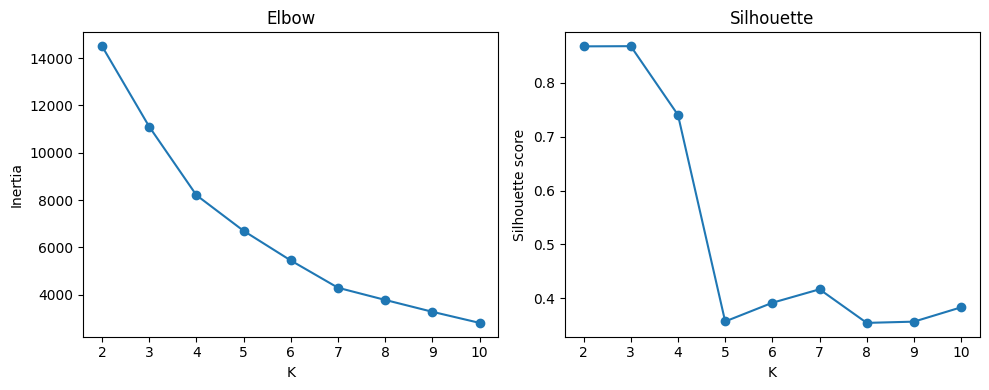

In [12]:
K_range = range(2, 11)
inertias = []
sils = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(train_scores)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(train_scores, lab))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(K_range, inertias, 'o-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow')
axes[1].plot(K_range, sils, 'o-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'clustering_elbow_silhouette.png', dpi=150)
plt.show()

In [13]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train['cluster'] = kmeans.fit_predict(train_scores)
val['cluster']   = kmeans.predict(val_scores)
test['cluster']  = kmeans.predict(test_scores)
summary = train.groupby('cluster')[TARGET].agg(['mean', 'count']).round(4)
summary.to_csv(OUTPUT_DIR / 'tables' / 'cluster_summary.csv')
print('Cluster summary (train set):')
display(summary)

Cluster summary (train set):


,mean,count
cluster,,
0,7.6634,1904
1,5.1414,74
2,19.6081,26
3,5.8351,13


## 5. Feedforward neural network

NN validation: {'RMSE': np.float64(1.9136848419677233), 'MAE': 1.033206726550525, 'R2': 0.900271363829857}
NN test: {'RMSE': np.float64(1.7071832956570339), 'MAE': 0.9871461709169926, 'R2': 0.9113626794586998}


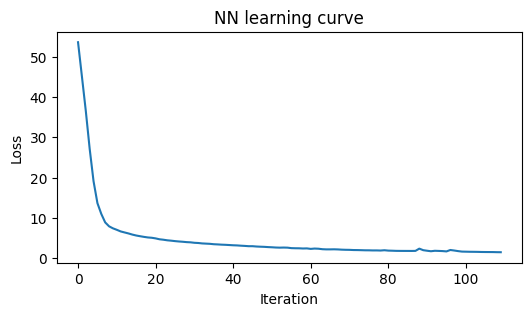

In [14]:
mlp = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', max_iter=500,
                   early_stopping=True, validation_fraction=0.1, random_state=42)
mlp.fit(X_train, y_train)
print('NN validation:', evaluate(y_val, mlp.predict(X_val)))
print('NN test:', evaluate(y_test, mlp.predict(X_test)))
if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(6, 3))
    plt.plot(mlp.loss_curve_)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('NN learning curve')
    plt.savefig(OUTPUT_DIR / 'figures' / 'nn_learning_curve.png', dpi=150)
    plt.show()

## 6. LSTM (panel time-series)

In [15]:
SEQ_LEN = 5
def build_sequences(df, pred_cols, target_col):
    X_list, y_list = [], []
    for country, g in df.sort_values('year').groupby('country'):
        g = g.sort_values('year')
        arr = g[pred_cols].values
        if len(arr) <= SEQ_LEN:
            continue
        for i in range(SEQ_LEN, len(arr)):
            X_list.append(arr[i-SEQ_LEN:i])
            y_list.append(g[target_col].iloc[i])
    return np.array(X_list), np.array(y_list)

train_full = pd.concat([train, val], ignore_index=True)
train_full[PREDICTOR_COLS] = scaler_X.transform(train_full[PREDICTOR_COLS])
X_seq_train, y_seq_train = build_sequences(train_full, PREDICTOR_COLS, TARGET)
test_scaled = test.copy()
test_scaled[PREDICTOR_COLS] = scaler_X.transform(test[PREDICTOR_COLS])
X_seq_test, y_seq_test = build_sequences(test_scaled, PREDICTOR_COLS, TARGET)
print('Train sequences:', X_seq_train.shape)
print('Test sequences:', X_seq_test.shape)

Train sequences: (1925, 5, 16)
Test sequences: (0,)


In [16]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_KERAS = True
except ImportError:
    HAS_KERAS = False
    print('TensorFlow not installed. LSTM section will be skipped. Install with: pip install tensorflow')

In [21]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [17]:
HAS_KERAS

True

In [18]:
if HAS_KERAS:
    model = keras.Sequential([
        layers.LSTM(64, return_sequences=False, input_shape=(SEQ_LEN, len(PREDICTOR_COLS))),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    hist = model.fit(X_seq_train, y_seq_train, epochs=30, batch_size=32, validation_split=0.15, verbose=0)
    pred_lstm = model.predict(X_seq_test, verbose=0).flatten()
    print('LSTM test:', evaluate(y_seq_test, pred_lstm))
    plt.figure(figsize=(6, 3))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.legend()
    plt.xlabel('Epoch')
    plt.title('LSTM loss')
    plt.savefig(OUTPUT_DIR / 'figures' / 'lstm_learning_curve.png', dpi=150)
    plt.show()
else:
    print('LSTM skipped (no Keras).')

UnboundLocalError: cannot access local variable 'batch_outputs' where it is not associated with a value

## 7. GNN (optional)

Build a graph: nodes = country-year or countries; edges from similarity (e.g. correlation of emissions over time). Then use a simple graph-aware model. Here we construct the graph and fit a baseline (mean neighbor features) as a placeholder; a full GCN would require PyTorch Geometric.

In [ ]:
country_means = df.groupby('country')[PREDICTOR_COLS + [TARGET]].mean()
corr = country_means.corr()
np.fill_diagonal(corr.values, 0)
threshold = 0.5
adj = (np.abs(corr) >= threshold).astype(float)
print('Graph: nodes = countries, edges = |correlation| >=', threshold)
print('Edges:', int(adj.sum().sum()//2))

In [ ]:
from scipy.sparse import csr_matrix
A = csr_matrix(adj.values)
row_sum = np.array(A.sum(axis=1)).flatten()
row_sum[row_sum == 0] = 1
A_norm = A.multiply(1.0 / row_sum[:, np.newaxis])
X_country = country_means[PREDICTOR_COLS].values
X_scaled = StandardScaler().fit_transform(X_country)
X_smooth = A_norm @ X_scaled
y_country = country_means[TARGET].values
from sklearn.linear_model import LinearRegression
gnn_baseline = LinearRegression().fit(X_smooth, y_country)
r2_gnn = gnn_baseline.score(X_smooth, y_country)
print('Graph-smoothed features + linear regression (country-level), R2:', round(r2_gnn, 4))
print('(Full GCN would use PyTorch Geometric for node-level prediction.)')

## Summary: model comparison

In [ ]:
comparison = []
for name, pred in [
    ('Linear', lm.predict(X_test)),
    ('Ridge', models['Ridge'].predict(X_test)),
    ('Lasso', models['Lasso'].predict(X_test)),
    ('ElasticNet', models['ElasticNet'].predict(X_test)),
    ('PCA+Linear', lm_pca.predict(test_scores)),
    ('MLP', mlp.predict(X_test)),
]:
    comparison.append({'model': name, **evaluate(y_test, pred)})
try:
    if HAS_KERAS and len(y_seq_test) > 0:
        comparison.append({'model': 'LSTM', **evaluate(y_seq_test, pred_lstm)})
except NameError:
    pass
pd.DataFrame(comparison).to_csv(OUTPUT_DIR / 'tables' / 'model_comparison.csv', index=False)
display(pd.DataFrame(comparison))